# Loading images to a pandas dataframe and categorize them between tumor and not tumor

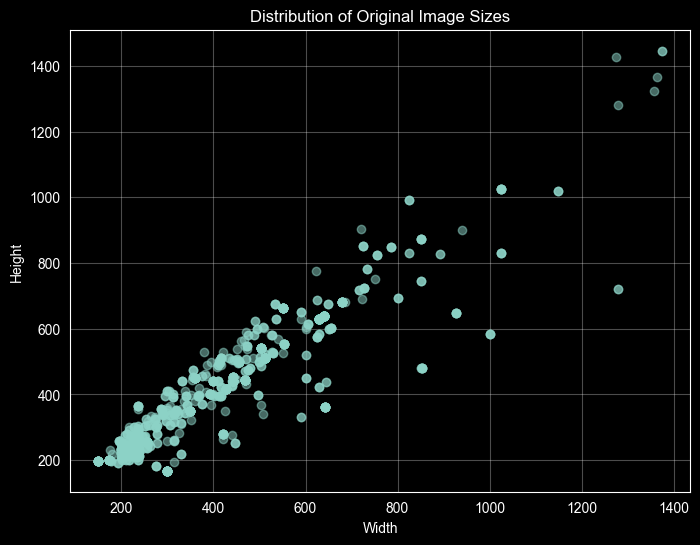

In [6]:
import os
import numpy as np
import skimage as ski
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog, graycomatrix, graycoprops
from skimage import exposure, filters
from skimage.restoration import denoise_tv_chambolle
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler

dataset_healthy = "./dataset/healthy"
dataset_tumor = "./dataset/tumor"
healthy_list = os.listdir(dataset_healthy)
tumor_list = os.listdir(dataset_tumor)

categories = [
    "healthy",
    "glioma",
    "meningioma",
    "pituitary",
    "tumor",
]

healthy_images = []
tumor_images = []


def categorize_img(name):
    for category in categories:
        if category in name:
            return category
    return "Unknown"


df = pd.DataFrame([], columns=["Img", "Category", "Tumor"])

original_sizes = []

for img in healthy_list:
    read_img = ski.io.imread(dataset_healthy + "/" + img)
    original_sizes.append(read_img.shape[:2])

for img in tumor_list:
    read_img = ski.io.imread(dataset_tumor + "/" + img)
    original_sizes.append(read_img.shape[:2])

heights = [s[0] for s in original_sizes]
widths = [s[1] for s in original_sizes]

plt.figure(figsize=(8,6))
plt.scatter(widths, heights, alpha=0.5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Distribution of Original Image Sizes")
plt.grid(alpha=0.3)
plt.show()

# Normalize

Images can have different sizes or color space differences so we need to convert them to use the same color space and size, if we check the charts we cna see that most of the images are around the 256x256 size so we will use size: 256x256 and Grayscale color space

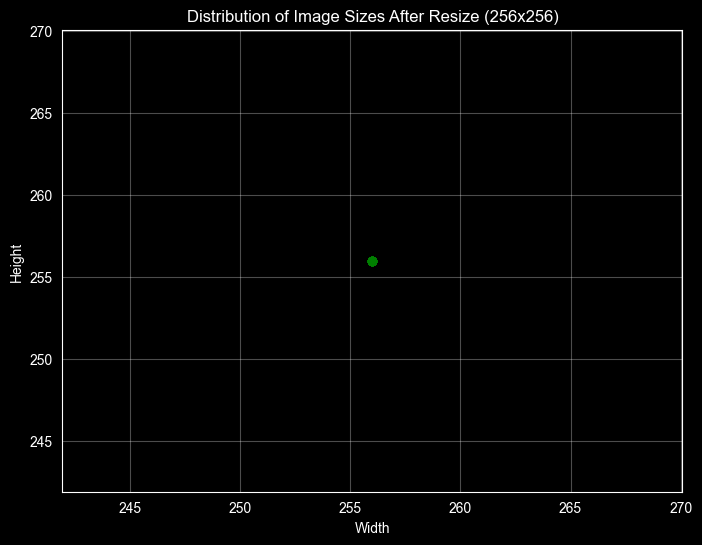

In [7]:
def normalize_color_space_img(img):
    if img.ndim == 2:
        return img
    elif img.ndim == 3:
        if img.shape[2] == 4:
            return ski.color.rgb2gray(ski.color.rgba2rgb(img))
        else:
            return ski.color.rgb2gray(img)
    else:
        print(f"Unexpected image shape: {img.shape}")
        return img

def normalize_size(img):
    return ski.transform.resize(img, (256, 256), anti_aliasing=True)

def preprocess_image(img):
    """Enhanced preprocessing with histogram equalization and denoising"""
    # Apply histogram equalization for better contrast
    img_eq = exposure.equalize_adapthist(img, clip_limit=0.03)
    # Apply denoising
    img_denoised = denoise_tv_chambolle(img_eq, weight=0.1)
    return img_denoised

for img in healthy_list:
    read_img = ski.io.imread(dataset_healthy + "/" + img)
    processed = preprocess_image(normalize_size(normalize_color_space_img(read_img)))
    df.loc[len(df)] = [processed, "healthy", 0]

for img in tumor_list:
    read_img = ski.io.imread(dataset_tumor + "/" + img)
    processed = preprocess_image(normalize_size(normalize_color_space_img(read_img)))
    df.loc[len(df)] = [processed, categorize_img(img), 1]

# Collect sizes after resizing
resized_sizes = []

for img_data in df["Img"]:
    resized_sizes.append(img_data.shape[:2])  # height, width

resized_heights = [s[0] for s in resized_sizes]
resized_widths = [s[1] for s in resized_sizes]

plt.figure(figsize=(8,6))
plt.scatter(resized_widths, resized_heights, alpha=0.5, color='green')
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Distribution of Image Sizes After Resize (256x256)")
plt.grid(alpha=0.3)
plt.show()

# Dataframe stats
We can see on the pie chart how balanced the dataset is, we have a good distribution between healthy and tumor images, and also we have a good distribution between the different types of tumors

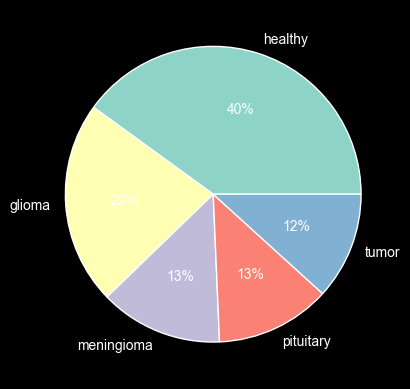

In [8]:
plt.pie(df["Category"].value_counts(), labels=categories, autopct='%.0f%%')
plt.show()

# Machine Learning - Binary Classification (Tumor vs Healthy)

We'll use comprehensive feature extraction:

- Histogram of Oriented Gradients (HOG) for shape and edge information
- Gray-Level Co-occurrence Matrix (GLCM) for texture analysis
- Statistical features (mean, std, median, percentiles) for intensity distribution
- Edge features using Sobel filters to capture boundary information



In [9]:
def extract_texture_features(img):
    """Extract GLCM texture features"""
    img_uint8 = (img * 255).astype(np.uint8)

    distances = [1, 2, 3]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(img_uint8, distances=distances, angles=angles,
                        levels=256, symmetric=True, normed=True)

    features = []
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
    for prop in props:
        feat = graycoprops(glcm, prop)
        features.extend(feat.flatten())

    return np.array(features)

def extract_statistical_features(img):
    """Extract statistical features from the image"""
    features = []

    features.append(np.mean(img))
    features.append(np.std(img))
    features.append(np.median(img))
    features.append(np.percentile(img, 25))
    features.append(np.percentile(img, 75))
    features.append(img.max() - img.min())

    edges = filters.sobel(img)
    features.append(np.mean(edges))
    features.append(np.std(edges))

    return np.array(features)

def extract_all_features(img):
    """Extract comprehensive features from an image"""
    hog_features = hog(
        img,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        visualize=False
    )

    texture_features = extract_texture_features(img)

    stat_features = extract_statistical_features(img)

    all_features = np.concatenate([hog_features, texture_features, stat_features])

    return all_features

print("Extracting features from images...")
X = df["Img"].apply(extract_all_features).tolist()
Y = df["Tumor"].tolist()

print(f"Feature vector size: {len(X[0])}")
print(f"Total samples: {len(X)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, random_state=42, test_size=0.2, stratify=Y)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

Extracting features from images...
Feature vector size: 8194
Total samples: 5000
Training samples: 4000, Test samples: 1000


# Model Training with Hyperparameter Tuning
Then we'll train a Support Vector Machine (SVM) with hyperparameter tuning with gridSearchCV that tests different values and finds the best ones.
We also use the model Random Forest classifier, and create an ensemble of both models for improved performance.

In [10]:
print("Training SVM with hyperparameter tuning...")

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01],
    'kernel': ['rbf', 'linear']
}

svm_clf = svm.SVC(random_state=42)
grid_search = GridSearchCV(svm_clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, Y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_:.4f}")

clf = grid_search.best_estimator_

Training SVM with hyperparameter tuning...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation score: 0.9698


# Train Random Forest and create Ensemble


Training Random Forest classifier...

Creating ensemble classifier...

=== SVM Results ===
Accuracy: 0.9860
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       400
           1       0.99      0.99      0.99       600

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


=== Random Forest Results ===
Accuracy: 0.9740
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       400
           1       0.98      0.98      0.98       600

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000


=== Ensemble Results ===
Accuracy: 0.9800
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       400
           1       0.99      0.97    

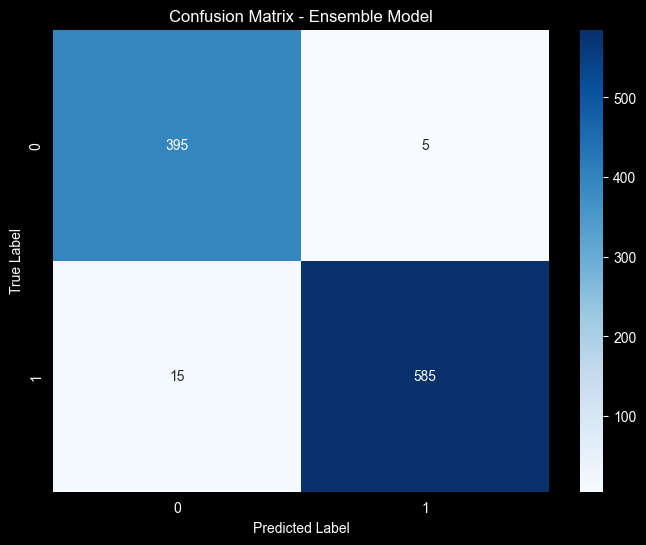

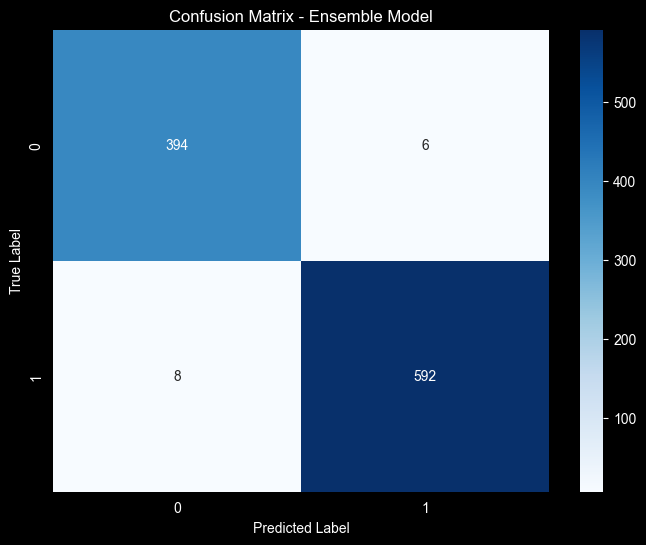

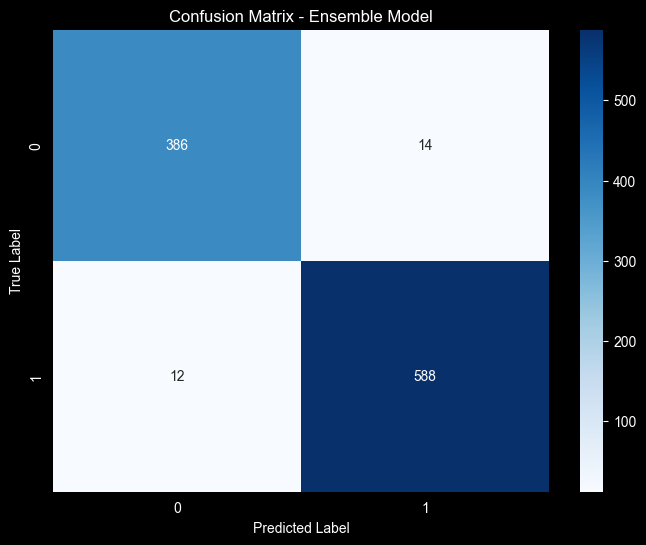

In [14]:
print("\nTraining Random Forest classifier...")
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, Y_train)

print("\nCreating ensemble classifier...")
ensemble_clf = VotingClassifier(
    estimators=[('svm', clf), ('rf', rf_clf)],
    voting='hard'
)
ensemble_clf.fit(X_train, Y_train)

print("\n=== SVM Results ===")
Y_pred_svm = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_svm):.4f}")
print(classification_report(Y_test, Y_pred_svm, zero_division=0))

print("\n=== Random Forest Results ===")
Y_pred_rf = rf_clf.predict(X_test)
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_rf):.4f}")
print(classification_report(Y_test, Y_pred_rf, zero_division=0))

print("\n=== Ensemble Results ===")
Y_pred_ensemble = ensemble_clf.predict(X_test)
print(f"Accuracy: {accuracy_score(Y_test, Y_pred_ensemble):.4f}")
print(classification_report(Y_test, Y_pred_ensemble, zero_division=0))

cm = confusion_matrix(Y_test, Y_pred_ensemble)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Ensemble Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cm = confusion_matrix(Y_test, Y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Ensemble Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cm = confusion_matrix(Y_test, Y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Ensemble Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Test on separate test dataset


TESTING ON EXTERNAL DATASET
External test set size: 815

=== SVM Results on External Dataset ===
Accuracy: 0.4896
              precision    recall  f1-score   support

           0       0.48      0.99      0.65       389
           1       0.86      0.03      0.05       426

    accuracy                           0.49       815
   macro avg       0.67      0.51      0.35       815
weighted avg       0.68      0.49      0.34       815


=== Random Forest Results on External Dataset ===
Accuracy: 0.4957
              precision    recall  f1-score   support

           0       0.49      0.99      0.65       389
           1       0.89      0.04      0.08       426

    accuracy                           0.50       815
   macro avg       0.69      0.52      0.36       815
weighted avg       0.70      0.50      0.35       815


=== Ensemble Results on External Dataset ===
Accuracy: 0.4847
              precision    recall  f1-score   support

           0       0.48      1.00      0.65  

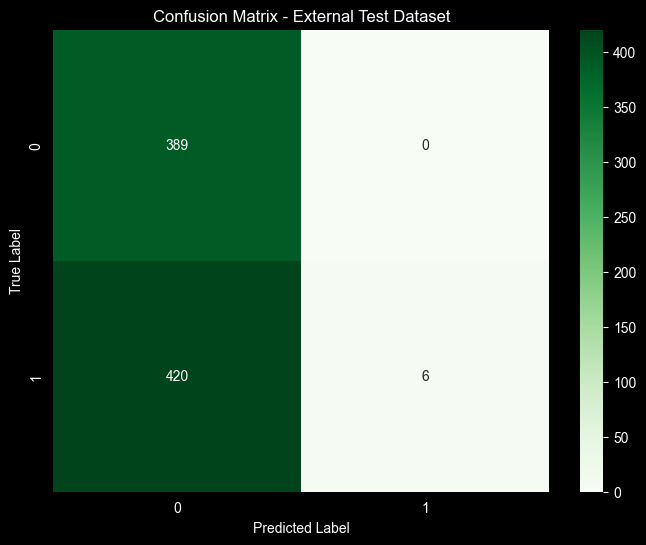

In [12]:
print("\n" + "="*50)
print("TESTING ON EXTERNAL DATASET")
print("="*50)

test_healthy = "./dataset/test_healthy"
test_tumor = "./dataset/test_tumor"
test_healthy_list = os.listdir(test_healthy)
test_tumor_list = os.listdir(test_tumor)

test_df = pd.DataFrame([], columns=["Img", "Tumor"])

for img in test_healthy_list:
    if not img.startswith('.'):  # Skip hidden files like .DS_Store
        read_img = ski.io.imread(test_healthy + "/" + img)
        processed = preprocess_image(normalize_size(normalize_color_space_img(read_img)))
        test_df.loc[len(test_df)] = [processed, 0]

for img in test_tumor_list:
    if not img.startswith('.'):
        read_img = ski.io.imread(test_tumor + "/" + img)
        processed = preprocess_image(normalize_size(normalize_color_space_img(read_img)))
        test_df.loc[len(test_df)] = [processed, 1]

print(f"External test set size: {len(test_df)}")

X_test_external = test_df["Img"].apply(extract_all_features).tolist()
Y_test_external = test_df["Tumor"].tolist()

X_test_external_scaled = scaler.transform(X_test_external)

print("\n=== SVM Results on External Dataset ===")
Y_pred_svm_ext = clf.predict(X_test_external_scaled)
print(f"Accuracy: {accuracy_score(Y_test_external, Y_pred_svm_ext):.4f}")
print(classification_report(Y_test_external, Y_pred_svm_ext, zero_division=0))

print("\n=== Random Forest Results on External Dataset ===")
Y_pred_rf_ext = rf_clf.predict(X_test_external_scaled)
print(f"Accuracy: {accuracy_score(Y_test_external, Y_pred_rf_ext):.4f}")
print(classification_report(Y_test_external, Y_pred_rf_ext, zero_division=0))

print("\n=== Ensemble Results on External Dataset ===")
Y_pred_ensemble_ext = ensemble_clf.predict(X_test_external_scaled)
print(f"Accuracy: {accuracy_score(Y_test_external, Y_pred_ensemble_ext):.4f}")
print(classification_report(Y_test_external, Y_pred_ensemble_ext, zero_division=0))

cm_ext = confusion_matrix(Y_test_external, Y_pred_ensemble_ext)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - External Test Dataset')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()